In [29]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [30]:
from cf_bench.config import SystemConfig
config = SystemConfig(backend="sklearn")
print(config)

=== System Config ===
backend                : sklearn
model_type             : classifier
target                 : hltprhc
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']
ordinal_features       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'dosprt']
continuous_features    : ['bmi']
ordinal_allowed_values : {'etfruit': [1, 2, 3, 4, 5, 6, 7], 'eatveg': [1, 2, 3, 4, 5, 6, 7], 'cgtsmok': [1, 2, 3, 4, 5, 6], 'alcfreq': [1, 2, 3, 4, 5, 6, 7], 'slprl': [1, 2, 3, 4], 'paccnois': [0, 1], 'dosprt': [0, 1, 2, 3, 4, 5, 6, 7]}
target_factor          : 0.5
features_to_vary       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [31]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [32]:
import pandas as pd

train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [33]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
32878,4,4,6,6,1,0,22.679952,0,0
32879,1,2,4,7,1,0,23.875115,5,0
32880,2,2,6,2,1,0,23.629490,4,1
32881,4,4,6,7,2,0,29.700413,0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [34]:
TARGET = config.target

In [35]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


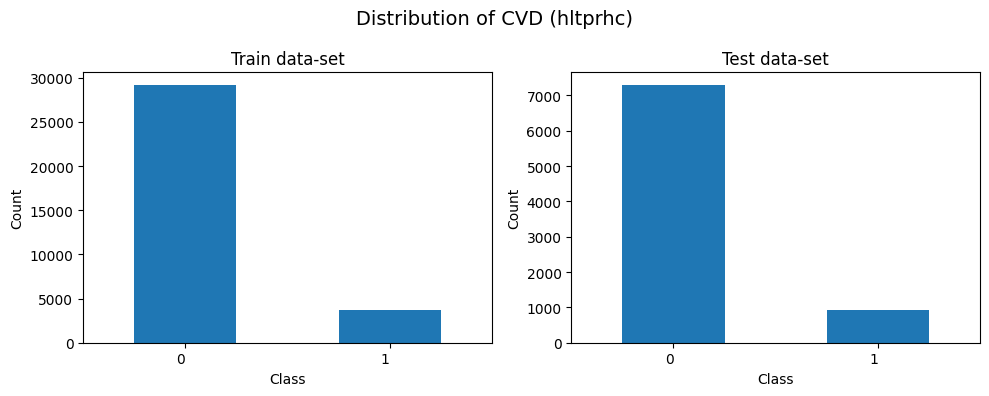

In [36]:
plot_target_distribution(train_df, test_df, TARGET, label="CVD")

In [37]:
# -------------------------
X = config.feature_cols
# -------------------------

y_train = train_df[TARGET]
X_train = train_df[X]

y_true = test_df[TARGET]
X_test = test_df[X]

# testing gridsearch on ESS-data, CVD (hltprhc) as target - XGBoost

In [38]:
from scipy.stats import randint, uniform

# first with 400 iterations
# cv5
first_param_dist = {
    "xgb__n_estimators": randint(200, 1200),
    # More boosting rounds. Needed if learning_rate is small.

    "xgb__max_depth": randint(3, 15),
    # Allow deeper trees. Can capture more complex interactions.

    "xgb__learning_rate": uniform(0.005, 0.3),
    # Wider range. Very small LR + many trees can improve recall.

    "xgb__subsample": uniform(0.3, 0.7),
    # Allow more randomness. Helps generalization.

    "xgb__colsample_bytree": uniform(0.3, 0.7),
    # Same here. Lower values often help with noisy tabular data.

    "xgb__min_child_weight": randint(1, 15),
    # Larger range. Higher values prevent overfitting.

    "xgb__gamma": uniform(0, 5),
    # Much wider. Stronger split regularization can help stability.

    "xgb__scale_pos_weight": [None], # NO WEIGHTS!

    "xgb__reg_lambda": uniform(0, 10),
    # Stronger L2 regularization. Helps noisy datasets.

    "xgb__reg_alpha": uniform(0, 10),
    # Stronger L1 regularization. Can simplify trees.
}

In [48]:
# Run 002: Refined based on Run 001 WITH reg_lambda/reg_alpha
# Key findings from Run 001 (top 20 models, mean_test_score 0.483-0.513):
# - Learning rates: 0.15-0.30 range performs best
# - Subsample: 0.3-0.8 (varied, more randomness than expected)
# - Colsample_bytree: 0.7-1.0 (high feature retention better)
# - Max_depth: 6-10 (NOT 10-14! Moderate depth wins)
# - n_estimators: 500-1200 (moderate to high ensemble)
# - min_child_weight: 1-12 (varied, explore full range)
# - gamma: 0-1.5 (low to moderate regularization)
# - reg_lambda: 1-8 (moderate L2 helps! Not just 0-3)
# - reg_alpha: 0-7 (L1 varied, some benefit from higher values)

param_dist_refined = {
    "xgb__n_estimators": randint(500, 1200),
    # Increased from 300-800. Top performers use 500-1200

    "xgb__max_depth": randint(6, 14),
    # CORRECTED: Was 8-15, but data shows 6-10 is optimal!

    "xgb__learning_rate": uniform(0.15, 0.15),  # 0.15-0.30
    # Confirmed: Higher learning rates (0.15-0.30) work better

    "xgb__subsample": uniform(0.3, 0.5),  # 0.30-0.80
    # Keep randomness, data shows 0.3-0.8 range effective

    "xgb__colsample_bytree": uniform(0.6, 0.4),  # 0.60-1.0
    # High feature retention (0.7-1.0) performs best

    "xgb__min_child_weight": randint(1, 13),
    # Full range 1-12, data shows varied optimal values

    "xgb__gamma": uniform(0, 1.5),
    # Reduced from 0-2. Top models use 0-1.5

    "xgb__scale_pos_weight": [None],
    # Keep None for CF compatibility

    "xgb__reg_lambda": uniform(1, 7),  # 1.0-8.0
    # IMPORTANT: Data shows L2 regularization helps (1-8 range)

    "xgb__reg_alpha": uniform(0, 7),  # 0.0-7.0
    # L1 regularization varies, some models benefit from higher values
}

In [49]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

pipeline = Pipeline([("xgb", XGBClassifier(eval_metric="logloss"))])


rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist_refined,
    n_iter=500,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)

rand.fit(X_train, y_train)

print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END xgb__colsample_bytree=0.749816047538945, xgb__gamma=1.4260714596148742, xgb__learning_rate=0.25979909127171075, xgb__max_depth=10, xgb__min_child_weight=5, xgb__n_estimators=1114, xgb__reg_alpha=3.120829269975138, xgb__reg_lambda=1.6998244107260203, xgb__scale_pos_weight=None, xgb__subsample=0.5296244459829336; total time=   2.0s
[CV] END xgb__colsample_bytree=0.749816047538945, xgb__gamma=1.4260714596148742, xgb__learning_rate=0.25979909127171075, xgb__max_depth=10, xgb__min_child_weight=5, xgb__n_estimators=1114, xgb__reg_alpha=3.120829269975138, xgb__reg_lambda=1.6998244107260203, xgb__scale_pos_weight=None, xgb__subsample=0.5296244459829336; total time=   2.0s
[CV] END xgb__colsample_bytree=0.7334834444556088, xgb__gamma=0.21430022688291117, xgb__learning_rate=0.24763327094232793, xgb__max_depth=10, xgb__min_child_weight=2, xgb__n_estimators=843, xgb__reg_alpha=5.827098485602952, xgb__reg_lambda=2.486373774747

In [50]:
res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,...,xgb__colsample_bytree,xgb__gamma,xgb__learning_rate,xgb__max_depth,xgb__min_child_weight,xgb__n_estimators,xgb__reg_alpha,xgb__reg_lambda,xgb__scale_pos_weight,xgb__subsample
375,2.880453,0.066448,0.320384,0.019841,0.522974,0.530957,0.522462,0.530592,0.521644,0.525726,...,0.968398,1.041893,0.259347,11.0,9.0,1092.0,0.216005,1.363267,NaN,0.371085
243,2.759810,0.077268,0.315666,0.043305,0.516559,0.524519,0.533069,0.520355,0.523367,0.523574,...,0.837218,0.587289,0.211893,13.0,7.0,904.0,0.203500,2.168196,NaN,0.390660
162,2.519188,0.083217,0.262464,0.017849,0.509728,0.522454,0.526839,0.533933,0.519954,0.522582,...,0.976495,0.108624,0.230136,6.0,1.0,1088.0,0.550049,3.778463,NaN,0.366358
173,2.360485,0.125832,0.253276,0.008926,0.517104,0.521831,0.523488,0.535035,0.513897,0.522271,...,0.988558,0.271465,0.278158,10.0,9.0,817.0,0.681754,3.835146,NaN,0.596459
460,2.546152,0.132056,0.307552,0.017408,0.518528,0.526922,0.523036,0.528011,0.513344,0.521968,...,0.688202,0.327311,0.281111,12.0,6.0,887.0,0.004574,7.094683,NaN,0.696297


In [51]:
desired_order = [
    # metrics
    "mean_fit_time", "std_fit_time",
    "mean_score_time", "std_score_time",
    "split0_test_score", "split1_test_score", "split2_test_score",
    "split3_test_score", "split4_test_score",
    "mean_test_score", "std_test_score", "rank_test_score",

    # parameters
    "xgb__n_estimators",
    "xgb__max_depth",
    "xgb__learning_rate",
    "xgb__subsample",
    "xgb__colsample_bytree",
    "xgb__min_child_weight",
    "xgb__gamma",
    "xgb__scale_pos_weight",
    "xgb__reg_lambda",
    "xgb__reg_alpha",
]

top_estimators = top_estimators[desired_order]
top_estimators

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,...,xgb__n_estimators,xgb__max_depth,xgb__learning_rate,xgb__subsample,xgb__colsample_bytree,xgb__min_child_weight,xgb__gamma,xgb__scale_pos_weight,xgb__reg_lambda,xgb__reg_alpha
375,2.880453,0.066448,0.320384,0.019841,0.522974,0.530957,0.522462,0.530592,0.521644,0.525726,...,1092.0,11.0,0.259347,0.371085,0.968398,9.0,1.041893,NaN,1.363267,0.216005
243,2.759810,0.077268,0.315666,0.043305,0.516559,0.524519,0.533069,0.520355,0.523367,0.523574,...,904.0,13.0,0.211893,0.390660,0.837218,7.0,0.587289,NaN,2.168196,0.203500
162,2.519188,0.083217,0.262464,0.017849,0.509728,0.522454,0.526839,0.533933,0.519954,0.522582,...,1088.0,6.0,0.230136,0.366358,0.976495,1.0,0.108624,NaN,3.778463,0.550049
173,2.360485,0.125832,0.253276,0.008926,0.517104,0.521831,0.523488,0.535035,0.513897,0.522271,...,817.0,10.0,0.278158,0.596459,0.988558,9.0,0.271465,NaN,3.835146,0.681754
460,2.546152,0.132056,0.307552,0.017408,0.518528,0.526922,0.523036,0.528011,0.513344,0.521968,...,887.0,12.0,0.281111,0.696297,0.688202,6.0,0.327311,NaN,7.094683,0.004574
357,1.887193,0.070248,0.232685,0.010687,0.520093,0.522968,0.522974,0.521040,0.520930,0.521601,...,543.0,11.0,0.234763,0.478515,0.866640,6.0,0.244050,NaN,1.063269,0.084722
390,2.146466,0.053168,0.222680,0.006378,0.516905,0.528992,0.523590,0.522019,0.516216,0.521544,...,912.0,9.0,0.190664,0.524542,0.844003,2.0,0.469361,NaN,1.819462,1.218572
414,1.600698,0.027336,0.172734,0.010116,0.516009,0.519188,0.524425,0.527400,0.520672,0.521539,...,692.0,12.0,0.265948,0.334523,0.905920,5.0,1.018347,NaN,6.549307,0.126868
467,3.325077,0.068059,0.404188,0.014530,0.516618,0.529941,0.523987,0.522298,0.513577,0.521284,...,980.0,12.0,0.235270,0.582891,0.679937,1.0,0.083288,NaN,5.741752,1.658533
480,2.754721,0.121113,0.334473,0.017585,0.514967,0.525856,0.517106,0.531669,0.516612,0.521242,...,736.0,13.0,0.188091,0.346084,0.977064,5.0,0.124101,NaN,3.530790,0.529628


### save to csv

In [52]:
def append_run(df_new:pd.DataFrame, csv_path):
    """
    Appends a new run to a CSV file, automatically generating an incrementing run_id.
    Ensures run_id is the first column.
    """
    df_new = df_new.copy()

    # Determine next run_id
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        next_id = df_existing["run_id"].max() + 1 if "run_id" in df_existing else 1
    else:
        next_id = 1

    # Assign run_id
    df_new["run_id"] = str(next_id).zfill(3)

    # round the decimals
    df_new = df_new.round(3)

    # Move run_id to the first column
    cols = ["run_id"] + [c for c in df_new.columns if c != "run_id"]
    df_new = df_new[cols]

    # Append or create file
    df_new.to_csv(
        csv_path,
        mode="a" if os.path.exists(csv_path) else "w",
        header=not os.path.exists(csv_path),
        index=False
    )


In [53]:
csv_grid_path = "xgb_gridsearch_runs.csv"

append_run(top_estimators, csv_grid_path)

### investigate run metrics

In [54]:
best_xgb = rand.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

In [55]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_true, best_xgb_pred))
print()
print("ROC AUC score:", roc_auc_score(y_true, best_xgb_pred), "\n")

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7287
           1       0.22      0.10      0.14       934

    accuracy                           0.86      8221
   macro avg       0.55      0.53      0.53      8221
weighted avg       0.82      0.86      0.83      8221


ROC AUC score: 0.5277059789969466 



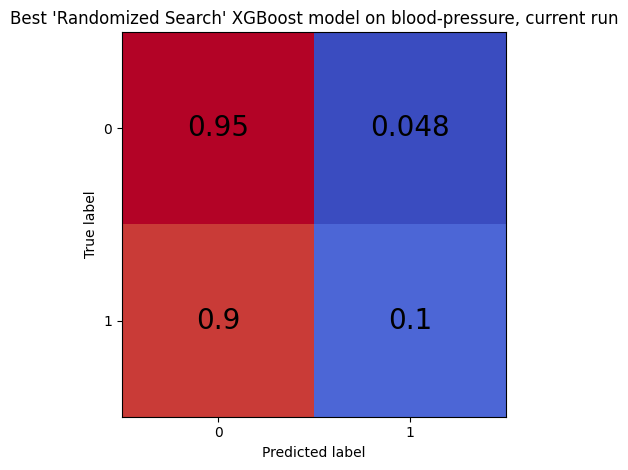

In [56]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_xgb_pred,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")

plt.title("Best 'Randomized Search' XGBoost model on blood-pressure, current run")
plt.tight_layout()
plt.show()